# EDA — Layer 1 & 2

**Goal of this notebook:** build intuition about the data before we model.
We go from simple to complex:
- **Layer 1** — look at each variable on its own.
- **Layer 2** — look at how each variable relates to `demand` (the target).

How to use this: run one cell at a time (Shift+Enter). Read the markdown note
above each cell first — it tells you what question the cell answers and what to
look for. After each section, pause and tell Claude what you saw.

## Setup
This cell loads the data and the tools. Run it first. It should print the
shapes of train and test. If it errors, the file paths in config.yaml are wrong.

In [1]:
import sys
from pathlib import Path

# Make sure we can import from src/ when running inside notebooks/
ROOT = Path.cwd()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent))

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import load_config
from src.data import load_raw

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)

cfg = load_config()
train, test = load_raw(cfg)
print("train shape:", train.shape)
print("test shape: ", test.shape)
print("\ncolumns:", list(train.columns))
train.head()

train shape: (77299, 13)
test shape:  (41778, 12)

columns: ['Index', 'geohash', 'day', 'timestamp', 'demand', 'RoadType', 'NumberofLanes', 'LargeVehicles', 'Landmarks', 'Temperature', 'Weather', 'minute', 'slot']


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather,minute,slot
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN,0,0
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny,0,0
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny,0,0
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy,0,0
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy,0,0


---
# LAYER 1 — Each variable on its own

Here we just look at what each column contains. No relationships yet. We want
to spot anything weird: strange values, heavy skew, surprising categories.

### 1.1 — The target: demand
**Question:** what does demand look like? Is it spread out evenly, or bunched up?
**Look for:** the shape. We already know it's skewed (a long tail of high values).
The second plot uses a log scale to see the small values better.

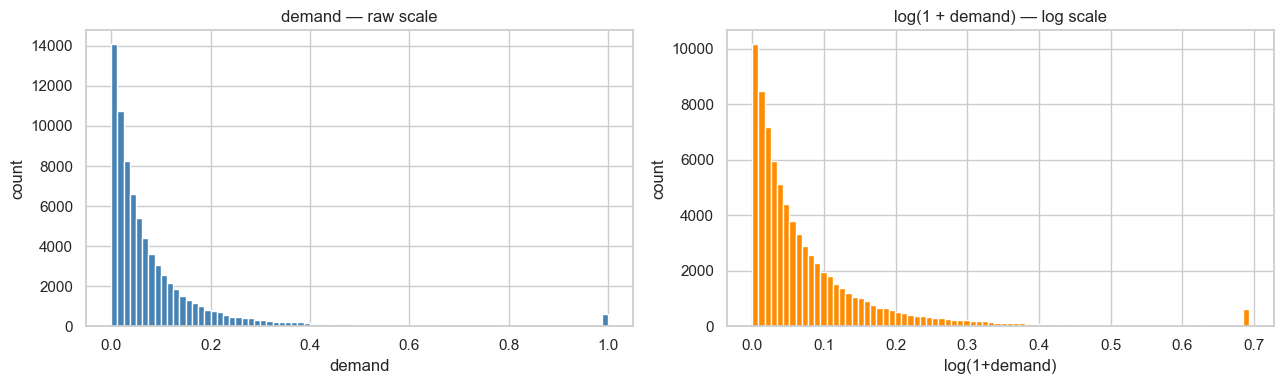

count    7.729900e+04
mean     9.394238e-02
std      1.421905e-01
min      6.245650e-07
25%      1.822723e-02
50%      4.775994e-02
75%      1.085951e-01
max      1.000000e+00
Name: demand, dtype: float64
skew: 3.729


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train["demand"], bins=80, color="steelblue")
axes[0].set_title("demand — raw scale")
axes[0].set_xlabel("demand"); axes[0].set_ylabel("count")

axes[1].hist(np.log1p(train["demand"]), bins=80, color="darkorange")
axes[1].set_title("log(1 + demand) — log scale")
axes[1].set_xlabel("log(1+demand)"); axes[1].set_ylabel("count")
plt.tight_layout(); plt.show()

print(train["demand"].describe())
print("skew:", round(train["demand"].skew(), 3))

### 1.2 — Time of day (slot)
**Question:** how many records do we have at each time of day? Is coverage even?
**Look for:** whether some times have way more/fewer records (they shouldn't,
much). `slot` runs 0 (midnight) to 95 (23:45), each step = 15 minutes.

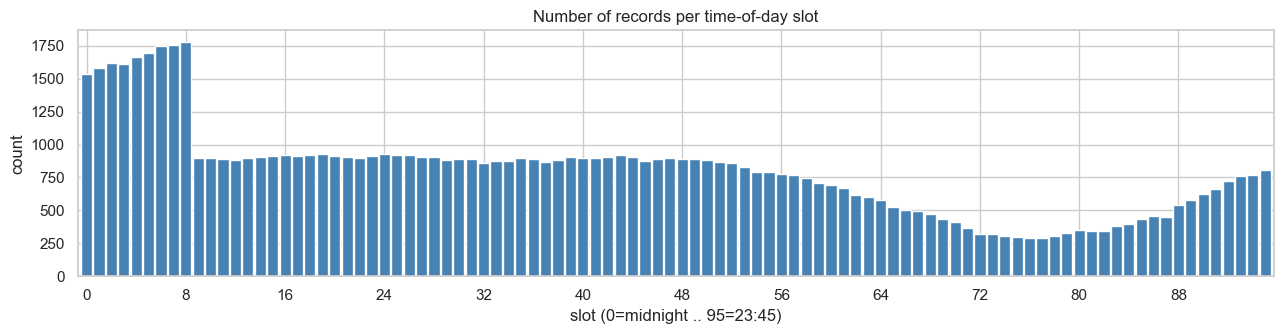

In [3]:
plt.figure(figsize=(13, 3.5))
train["slot"].value_counts().sort_index().plot(kind="bar", color="steelblue", width=0.9)
plt.title("Number of records per time-of-day slot")
plt.xlabel("slot (0=midnight .. 95=23:45)"); plt.ylabel("count")
plt.xticks(range(0, 96, 8), rotation=0)
plt.tight_layout(); plt.show()

### 1.3 — The categorical columns
**Question:** what categories exist and how common is each?
**Look for:** rare categories, the NaN (missing) counts, anything unexpected.

In [4]:
cat_cols = cfg["data"]["categorical"]   # RoadType, LargeVehicles, Landmarks, Weather
for c in cat_cols:
    print(f"\n=== {c} ===")
    print(train[c].value_counts(dropna=False))


=== RoadType ===
RoadType
Residential    69230
Street          3909
Highway         3560
NaN              600
Name: count, dtype: int64

=== LargeVehicles ===
LargeVehicles
Not Allowed    50673
Allowed        26626
Name: count, dtype: int64

=== Landmarks ===
Landmarks
Yes    52042
No     25257
Name: count, dtype: int64

=== Weather ===
Weather
Sunny    27717
Rainy    20824
Foggy    20243
Snowy     7718
NaN        797
Name: count, dtype: int64


### 1.4 — The numeric columns
**Question:** what range do NumberofLanes and Temperature cover?
**Look for:** the spread, any impossible values, the missing-value count.

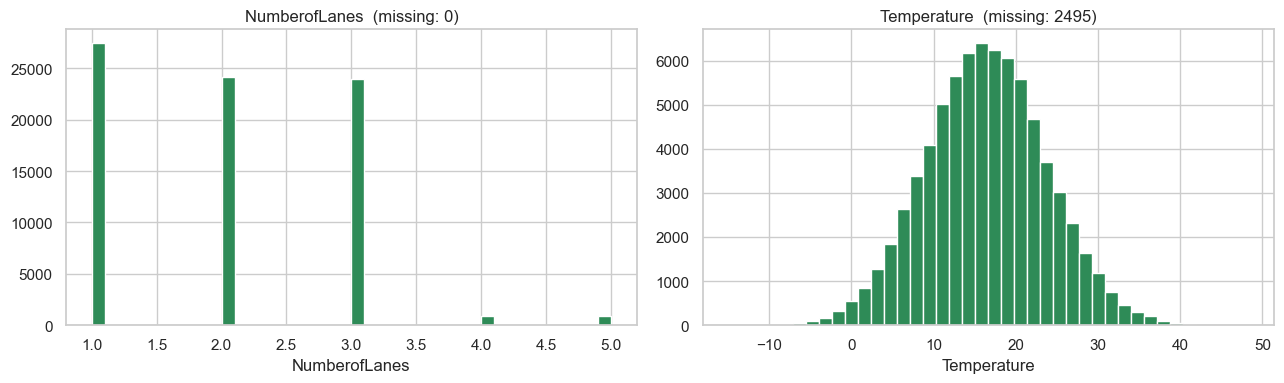

       NumberofLanes   Temperature
count   77299.000000  74804.000000
mean        2.014334     16.405354
std         0.904665      7.359835
min         1.000000    -14.935097
25%         1.000000     11.430473
50%         2.000000     16.382587
75%         3.000000     21.298833
max         5.000000     48.251433


In [5]:
num_cols = cfg["data"]["numeric"]   # NumberofLanes, Temperature
fig, axes = plt.subplots(1, len(num_cols), figsize=(13, 4))
for ax, c in zip(axes, num_cols):
    ax.hist(train[c].dropna(), bins=40, color="seagreen")
    ax.set_title(f"{c}  (missing: {train[c].isna().sum()})")
    ax.set_xlabel(c)
plt.tight_layout(); plt.show()
print(train[num_cols].describe())

---
# LAYER 2 — Each variable vs demand

Now the real questions. For each variable we ask: **does demand change when this
variable changes?** If yes, that variable is a useful signal. If demand is flat
no matter what the variable does, that variable is probably useless.

### 2.1 — Demand vs time of day  (THE most important single relationship)
**Question:** does traffic demand follow a daily rhythm?
**Look for:** peaks and dips. Real traffic usually peaks at rush hours and dies
at night. The shaded band shows the spread (how much locations differ at that time).

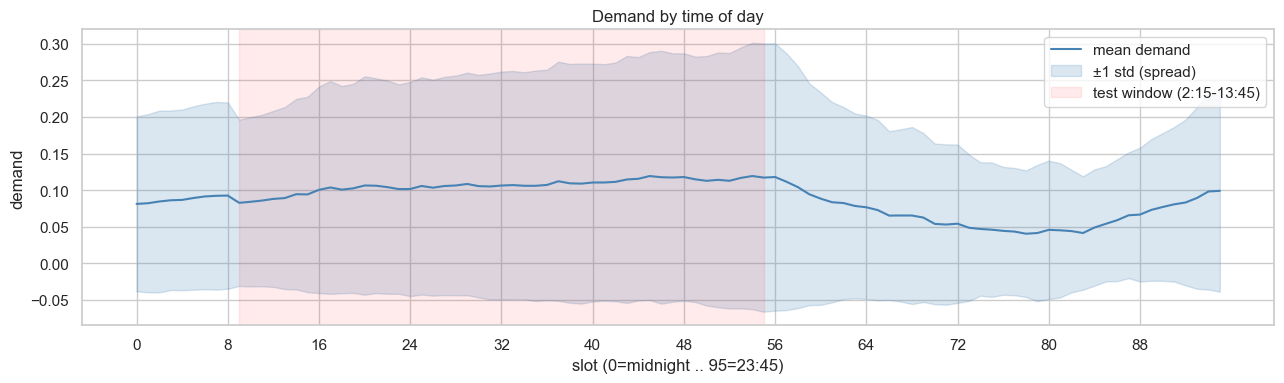

In [6]:
slot_stats = train.groupby("slot")["demand"].agg(["mean", "std"])
plt.figure(figsize=(13, 4))
plt.plot(slot_stats.index, slot_stats["mean"], color="steelblue", label="mean demand")
plt.fill_between(slot_stats.index,
                 slot_stats["mean"] - slot_stats["std"],
                 slot_stats["mean"] + slot_stats["std"],
                 alpha=0.2, color="steelblue", label="±1 std (spread)")
plt.axvspan(9, 55, alpha=0.08, color="red", label="test window (2:15-13:45)")
plt.title("Demand by time of day")
plt.xlabel("slot (0=midnight .. 95=23:45)"); plt.ylabel("demand")
plt.xticks(range(0, 96, 8)); plt.legend(); plt.tight_layout(); plt.show()

### 2.2 — Demand vs each categorical
**Question:** does demand differ by road type? by weather? etc.
**Look for:** boxes sitting at clearly different heights = that variable matters.
Boxes all at the same height = that variable probably doesn't matter much.

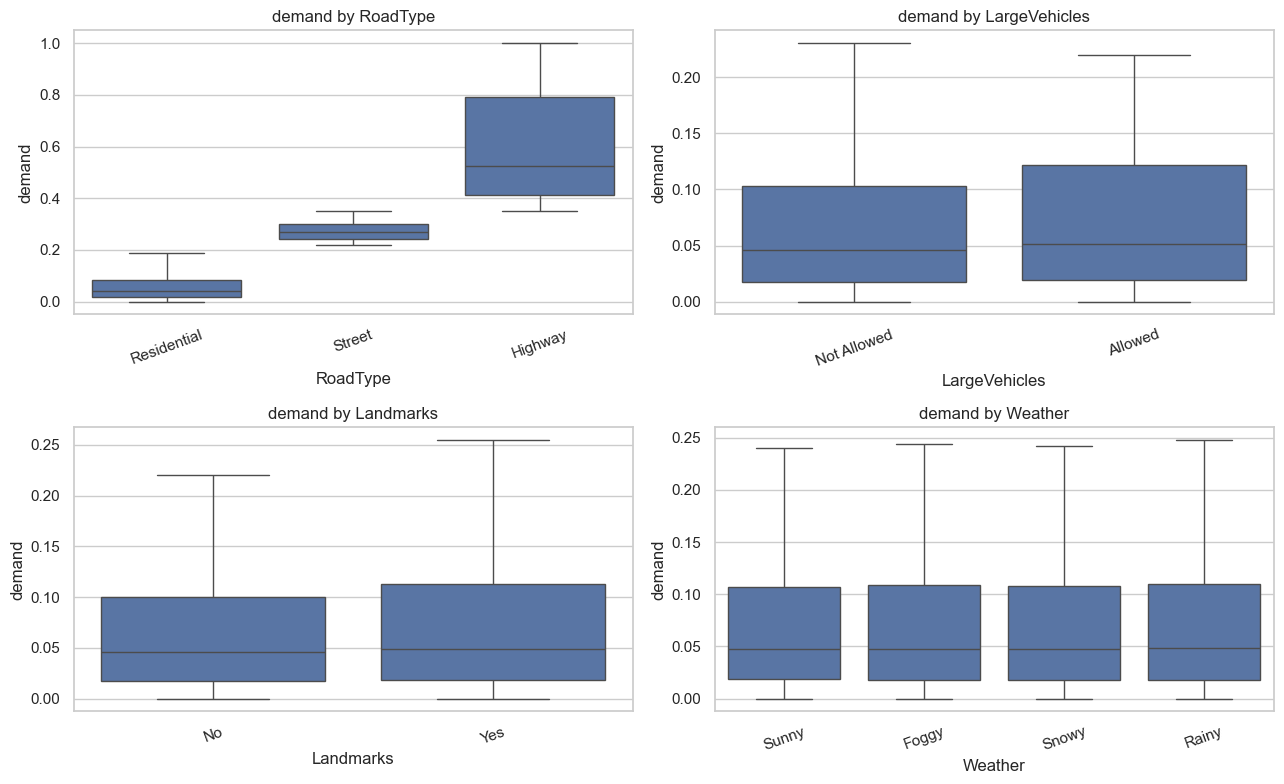


mean demand by RoadType:
RoadType
Highway        0.610756
Street         0.273164
Residential    0.057209
Name: demand, dtype: float64

mean demand by LargeVehicles:
LargeVehicles
Allowed        0.131923
Not Allowed    0.073986
Name: demand, dtype: float64

mean demand by Landmarks:
Landmarks
No     0.096295
Yes    0.092801
Name: demand, dtype: float64

mean demand by Weather:
Weather
Rainy    0.094471
Sunny    0.094247
Foggy    0.093372
Snowy    0.092581
Name: demand, dtype: float64


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, c in zip(axes.ravel(), cat_cols):
    order = train.groupby(c)["demand"].median().sort_values().index
    sns.boxplot(data=train, x=c, y="demand", order=order, ax=ax, showfliers=False)
    ax.set_title(f"demand by {c}")
    ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()

# Also print the average demand per category so you have exact numbers
for c in cat_cols:
    print(f"\nmean demand by {c}:")
    print(train.groupby(c)["demand"].mean().sort_values(ascending=False))

### 2.3 — Demand vs numeric variables
**Question:** does demand rise/fall with number of lanes or temperature?
**Look for:** a visible trend (line going up or down). Flat = no relationship.

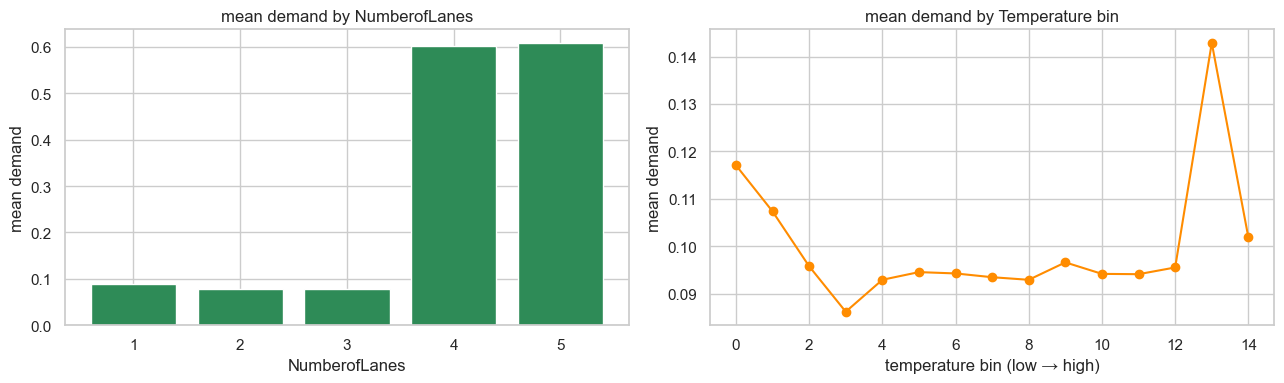

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# NumberofLanes: average demand per lane count
lane_mean = train.groupby("NumberofLanes")["demand"].mean()
axes[0].bar(lane_mean.index, lane_mean.values, color="seagreen")
axes[0].set_title("mean demand by NumberofLanes")
axes[0].set_xlabel("NumberofLanes"); axes[0].set_ylabel("mean demand")

# Temperature: bin into ranges, average demand per bin
tmp = train.dropna(subset=["Temperature"]).copy()
tmp["temp_bin"] = pd.cut(tmp["Temperature"], bins=15)
temp_mean = tmp.groupby("temp_bin", observed=True)["demand"].mean()
axes[1].plot(range(len(temp_mean)), temp_mean.values, marker="o", color="darkorange")
axes[1].set_title("mean demand by Temperature bin")
axes[1].set_xlabel("temperature bin (low → high)"); axes[1].set_ylabel("mean demand")
plt.tight_layout(); plt.show()

---
## End of Layer 1 & 2

Pause here. Go back through the plots and note, for each variable, whether it
seemed to **matter** for demand (demand changed with it) or **not** (demand was
flat). Bring those observations to Claude. Based on what actually matters, we'll
decide which combinations to dig into in Layer 3, and then tackle the big
day-over-day question in Layer 4.